# 3주차. 모델 설계 및 학습, 평가
### 주제: DACON 갑상선암 진단 분류 데이터

1~2주차에서 수행한 EDA와 전처리 결과를 바탕으로 분류 모델을 설계, 학습, 평가한다.

**지금까지의 요약**
- 결측치·이상치: 없음
- 타겟(Cancer) 불균형: 양성(0) 88.0% / 악성(1) 12.0%
- 전처리: 이진 범주형 Binary Encoding, 다범주형(Country, Race) One-Hot Encoding, 수치형 5종 StandardScaler
- Feature Engineering: 가족력·방사선노출·요오드결핍 합산 Risk_Score(0~3) 파생 변수, 값이 커질수록 악성 비율 증가

## 0. 라이브러리 불러오기 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              RocCurveDisplay)

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Noto Sans CJK JP'  # 한글 폰트 (seaborn 스타일 적용 이후 재설정)
plt.rcParams['axes.unicode_minus'] = False

train = pd.read_csv('train.csv')
print('train:', train.shape)
train.head()

train: (87159, 16)


,ID,Age,Gender,Country,Race,Family_Background,Radiation_History,Iodine_Deficiency,Smoke,Weight_Risk,Diabetes,Nodule_Size,TSH_Result,T4_Result,T3_Result,Cancer
0,TRAIN_00000,80,M,CHN,ASN,Positive,Exposed,Sufficient,Non-Smoker,Not Obese,No,0.650355,2.784735,6.744603,2.575820,1
1,TRAIN_00001,37,M,NGA,ASN,Positive,Unexposed,Sufficient,Smoker,Obese,No,2.950430,0.911624,7.303305,2.505317,1
2,TRAIN_00002,71,M,CHN,MDE,Positive,Unexposed,Sufficient,Non-Smoker,Not Obese,Yes,2.200023,0.717754,11.137459,2.381080,0
3,TRAIN_00003,40,F,IND,HSP,Negative,Unexposed,Sufficient,Non-Smoker,Obese,No,3.370796,6.846380,10.175254,0.753023,0
4,TRAIN_00004,53,F,CHN,CAU,Negative,Unexposed,Sufficient,Non-Smoker,Not Obese,No,4.230048,0.439519,7.194450,0.569356,1


## 0-1. 2주차 전처리 재적용

2주차에서 확정한 방식(이진 Binary Encoding, 다범주형 One-Hot Encoding, 수치형 StandardScaler,
Risk_Score 파생 변수)을 그대로 적용하여 모델 입력용 데이터셋을 만든다.

In [2]:
num_cols = ['Age', 'Nodule_Size', 'TSH_Result', 'T4_Result', 'T3_Result']
binary_cols = ['Gender', 'Family_Background', 'Radiation_History', 'Iodine_Deficiency',
               'Smoke', 'Weight_Risk', 'Diabetes']
multi_cat_cols = ['Country', 'Race']

df = train.copy()

# Risk_Score 파생 변수 (인코딩 전 원본 범주 기준)
df['Risk_Score'] = (
    (df['Family_Background'] == 'Positive').astype(int) +
    (df['Radiation_History'] == 'Exposed').astype(int) +
    (df['Iodine_Deficiency'] == 'Deficient').astype(int)
)

# 이진 범주형 Binary Encoding
for col in binary_cols:
    mapping = {cat: i for i, cat in enumerate(sorted(df[col].unique()))}
    df[col] = df[col].map(mapping)

# 다범주형 One-Hot Encoding
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe_arr = ohe.fit_transform(df[multi_cat_cols])
ohe_df = pd.DataFrame(ohe_arr, columns=ohe.get_feature_names_out(multi_cat_cols), index=df.index)
df = pd.concat([df.drop(columns=multi_cat_cols), ohe_df], axis=1)

X = df.drop(columns=['ID', 'Cancer'])
y = df['Cancer']

print('입력 변수 shape:', X.shape)
X.head()

입력 변수 shape: (87159, 28)


,Age,Gender,Family_Background,Radiation_History,Iodine_Deficiency,Smoke,Weight_Risk,Diabetes,Nodule_Size,TSH_Result,...,Country_JPN,Country_KOR,Country_NGA,Country_RUS,Country_USA,Race_AFR,Race_ASN,Race_CAU,Race_HSP,Race_MDE
0,80,1,1,0,1,0,0,0,0.650355,2.784735,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,37,1,1,1,1,1,1,0,2.950430,0.911624,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,71,1,1,1,1,0,0,1,2.200023,0.717754,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,40,0,0,1,1,0,1,0,3.370796,6.846380,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,53,0,0,1,1,0,0,0,4.230048,0.439519,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 3-1. 머신러닝 이론

**머신러닝이란 무엇인가**
머신러닝(Machine Learning)은 정답이 정해진 규칙을 사람이 직접 프로그래밍하는 대신, 데이터를 통해 패턴을
스스로 학습하여 새로운 입력에 대한 예측을 수행하는 알고리즘 및 모델을 다루는 분야이다. 데이터와 정답(레이블)이
주어지면 모델이 입력과 출력 사이의 관계를 학습하고(지도학습), 정답 없이 데이터의 구조나 군집을 찾기도 한다
(비지도학습).

**분류(Classification)와 회귀(Regression)의 차이**
- **분류(Classification):** 출력값이 '양성/악성', '스팸/정상' 처럼 이산적인 범주(클래스)인 문제이다. 본 과제의
  Cancer(0/1) 예측이 대표적인 이진 분류 문제이다.
- **회귀(Regression):** 출력값이 연속적인 수치인 문제이다. 예를 들어 집값이나 온도를 예측하는 문제가 회귀에
  해당한다. 즉, 분류는 '어떤 범주에 속하는가'를, 회귀는 '얼마인가'를 예측한다는 점에서 다르다.

**대표적인 머신러닝 모델 3가지와 특징**
1. **로지스틱 회귀(Logistic Regression):** 선형 결합에 시그모이드 함수를 적용하여 클래스에 속할 확률을
   추정하는 분류 모델이다. 구조가 단순하고 해석이 쉬우며 학습 속도가 빠르지만, 변수 간 비선형 관계를
   포착하기 어렵다는 한계가 있다.
2. **결정 트리(Decision Tree):** 변수 기준으로 데이터를 반복적으로 분할하여 트리 형태의 규칙을 만드는 모델이다.
   해석이 직관적이고 스케일링이 필요 없지만, 트리가 깊어지면 과적합되기 쉽다.
3. **랜덤 포레스트(Random Forest):** 여러 개의 결정 트리를 배깅(Bagging) 방식으로 앙상블하여 각 트리의
   예측을 종합(다수결/평균)하는 모델이다. 단일 트리보다 과적합에 강하고 변수 중요도를 함께 제공하지만,
   개별 트리보다 해석이 어렵고 학습 비용이 크다.

## 3-2. 데이터 분할

**Train / Test 분할**
DACON에서 제공한 test.csv는 Cancer(정답) 레이블이 없는 실제 제출용 평가 데이터이므로, 모델의 성능을 직접
확인할 수 없다. 따라서 레이블이 있는 train.csv를 다시 **학습용(Train, 80%)**과 **검증용(Validation, 20%)**으로
분할하여, 검증용 데이터로 모델 성능을 사전에 가늠한다.

**데이터를 분리하여 학습하는 이유**
모델을 학습에 사용한 데이터로 그대로 평가하면 모델이 그 데이터를 '암기'했을 뿐인지, 실제로 일반화된 패턴을
학습했는지 구분할 수 없다. 학습에 전혀 사용하지 않은 데이터로 평가해야 새로운(미래의) 데이터에 대한 예측
성능을 신뢰성 있게 추정할 수 있으며, 이를 통해 과적합(Overfitting) 여부도 점검할 수 있다. 또한 타겟 클래스가
88:12로 불균형하므로, 분할 시 <code>stratify</code> 옵션으로 학습/검증 데이터의 클래스 비율을 동일하게
유지하였다.

In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train:', X_train.shape, ' X_val:', X_val.shape)
print()
print('학습 데이터 Cancer 비율:')
print(y_train.value_counts(normalize=True).round(3))
print()
print('검증 데이터 Cancer 비율:')
print(y_val.value_counts(normalize=True).round(3))

X_train: (69727, 28)  X_val: (17432, 28)

학습 데이터 Cancer 비율:
Cancer
0    0.88
1    0.12
Name: proportion, dtype: float64

검증 데이터 Cancer 비율:
Cancer
0    0.88
1    0.12
Name: proportion, dtype: float64


In [4]:
# 수치형 변수 Scaling (train으로 fit, val은 transform만 -> 데이터 누수 방지)
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
print('Scaling 완료')

Scaling 완료


## 3-3. 모델 학습

**모델 선택 이유**
비교를 위해 서로 다른 성격의 모델 두 가지를 학습한다.
- **로지스틱 회귀:** 해석이 쉬운 선형 모델로, 성능의 기준선(baseline)을 확인하기 위해 사용한다.
- **랜덤 포레스트:** 변수 간 비선형적 상호작용(예: Risk_Score와 다른 변수의 조합 효과)을 포착할 수 있고,
  범주형·수치형이 섞인 표 형태 데이터에서 일반적으로 우수한 성능을 보이며, 변수 중요도를 함께 확인할 수
  있어 선택하였다.

두 모델 모두 타겟 불균형(88:12)을 고려하여 <code>class_weight='balanced'</code> 옵션을 적용하였다. 이는
소수 클래스(악성)의 오분류에 더 큰 가중치를 부여하여, 모델이 다수 클래스(양성)만 예측하는 방향으로
치우치는 것을 완화하기 위함이다.

**사용한 하이퍼파라미터**
- 로지스틱 회귀: `max_iter=1000`, `class_weight='balanced'` (나머지는 기본값)
- 랜덤 포레스트: `n_estimators=300`(트리 개수), `max_depth=10`(과적합 방지를 위한 트리 깊이 제한),
  `class_weight='balanced'`, `random_state=42`

**학습 과정**
학습용 데이터(X_train, y_train)로 두 모델을 각각 `fit()`하고, 검증용 데이터(X_val, y_val)에 대한 예측
확률과 예측 클래스를 구하여 3-4에서 비교한다.

In [5]:
# 로지스틱 회귀
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train, y_train)

# 랜덤 포레스트
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

print('학습 완료')

학습 완료


## 3-4. 모델 평가

**평가 지표 설명**
- **Accuracy(정확도):** 전체 예측 중 맞춘 비율. 클래스 불균형이 심한 경우(본 데이터 88:12) 다수 클래스만
  예측해도 높게 나올 수 있어 단독으로는 신뢰하기 어렵다.
- **Precision(정밀도):** 모델이 '악성'이라고 예측한 것 중 실제로 악성인 비율. 정상을 악성으로 잘못 예측하는
  것(위양성)을 얼마나 피했는지를 나타낸다.
- **Recall(재현율):** 실제 악성 중 모델이 악성으로 맞게 예측한 비율. 실제 악성 환자를 놓치지 않는지(위음성
  최소화)를 나타낸다. 암 진단 문제에서는 특히 Recall이 중요한데, 실제 악성을 정상으로 오진하면(위음성)
  치료 시기를 놓칠 수 있기 때문이다.
- **F1-score:** Precision과 Recall의 조화평균으로, 두 지표의 균형을 하나의 값으로 요약한다.
- **ROC-AUC:** 임계값(threshold)을 변화시켜가며 True Positive Rate와 False Positive Rate의 관계를 그린
  ROC 곡선 아래 면적으로, 임계값에 무관하게 모델의 전반적인 분류 성능을 나타낸다(1에 가까울수록 우수).

In [6]:
def evaluate(model, name, X_val, y_val):
    pred = model.predict(X_val)
    proba = model.predict_proba(X_val)[:, 1]

    acc = accuracy_score(y_val, pred)
    prec = precision_score(y_val, pred)
    rec = recall_score(y_val, pred)
    f1 = f1_score(y_val, pred)
    auc = roc_auc_score(y_val, proba)

    print(f'--- {name} ---')
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall   : {rec:.4f}')
    print(f'F1-score : {f1:.4f}')
    print(f'ROC-AUC  : {auc:.4f}')
    print()
    return {'model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec,
            'F1': f1, 'ROC-AUC': auc, 'pred': pred, 'proba': proba}

result_log = evaluate(log_reg, 'Logistic Regression', X_val, y_val)
result_rf = evaluate(rf, 'Random Forest', X_val, y_val)

--- Logistic Regression ---
Accuracy : 0.6538
Precision: 0.1967
Recall   : 0.6114
F1-score : 0.2977
ROC-AUC  : 0.6686



--- Random Forest ---
Accuracy : 0.8799
Precision: 0.4995
Recall   : 0.4412
F1-score : 0.4685
ROC-AUC  : 0.6850



In [7]:
results_df = pd.DataFrame([
    {k: v for k, v in result_log.items() if k in ['model','Accuracy','Precision','Recall','F1','ROC-AUC']},
    {k: v for k, v in result_rf.items() if k in ['model','Accuracy','Precision','Recall','F1','ROC-AUC']},
]).set_index('model')
results_df.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
model,,,,,
Logistic Regression,0.6538,0.1967,0.6114,0.2977,0.6686
Random Forest,0.8799,0.4995,0.4412,0.4685,0.6850


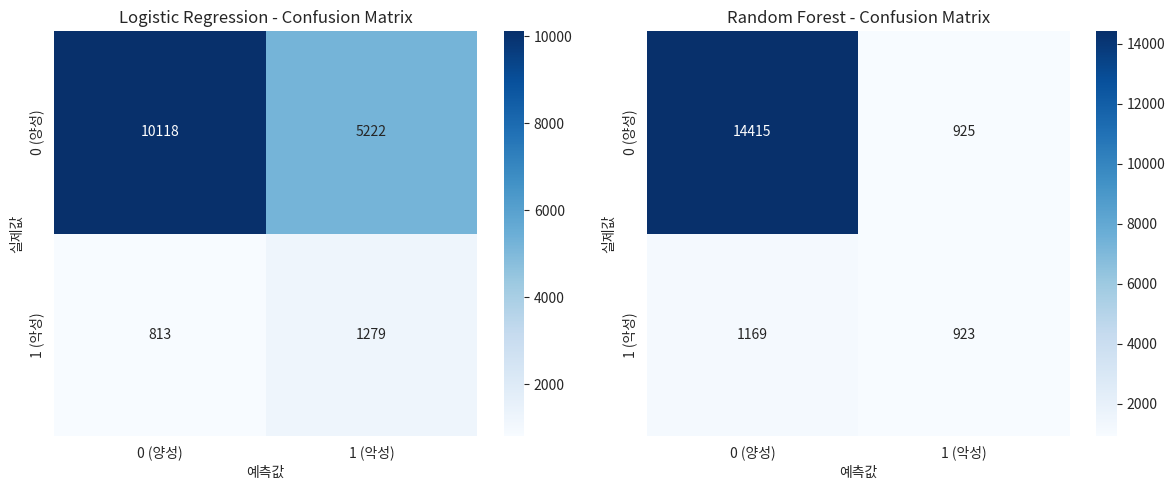

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, res, name in zip(axes, [result_log, result_rf], ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_val, res['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['0 (양성)', '1 (악성)'], yticklabels=['0 (양성)', '1 (악성)'])
    ax.set_title(f'{name} - Confusion Matrix')
    ax.set_xlabel('예측값')
    ax.set_ylabel('실제값')

plt.tight_layout()
plt.savefig('imgs3/01_confusion_matrix.png', dpi=120)
plt.show()

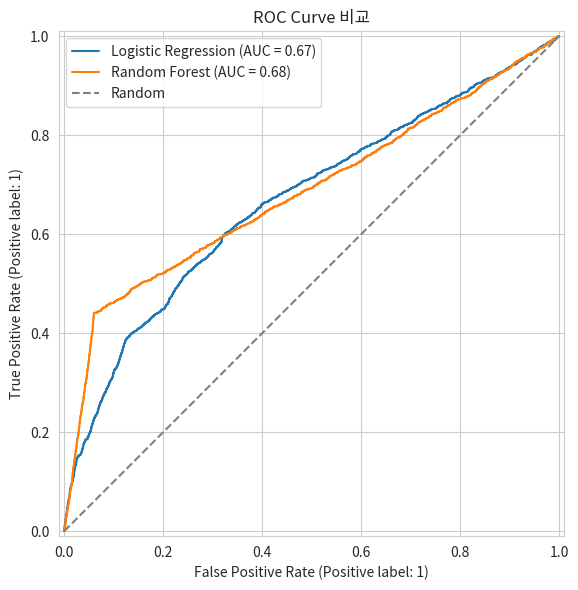

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_val, result_log['proba'], name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_val, result_rf['proba'], name='Random Forest', ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
ax.set_title('ROC Curve 비교')
ax.legend()
plt.tight_layout()
plt.savefig('imgs3/02_roc_curve.png', dpi=120)
plt.show()

### 변수 중요도 (Random Forest)

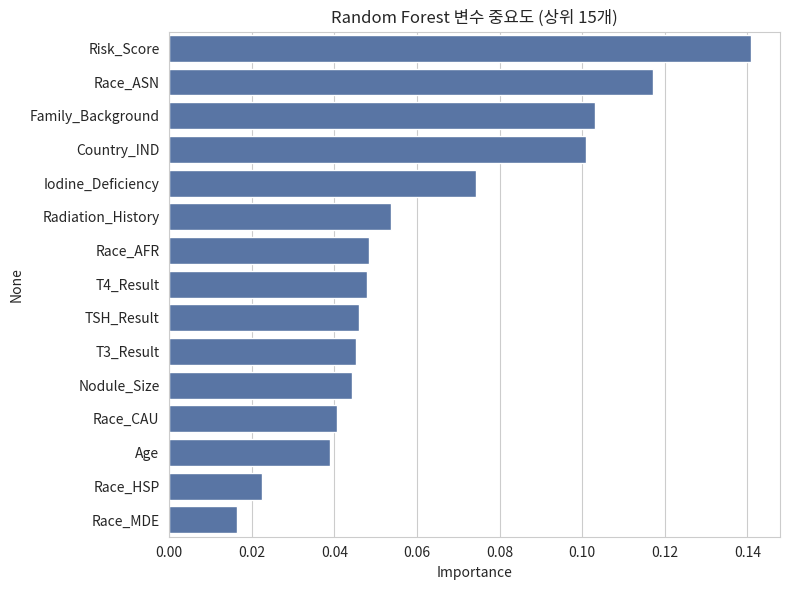

Risk_Score           0.140860
Race_ASN             0.117047
Family_Background    0.103062
Country_IND          0.100899
Iodine_Deficiency    0.074282
Radiation_History    0.053752
Race_AFR             0.048380
T4_Result            0.047771
TSH_Result           0.046041
T3_Result            0.045207
Nodule_Size          0.044199
Race_CAU             0.040570
Age                  0.038807
Race_HSP             0.022556
Race_MDE             0.016454
dtype: float64

In [10]:
importance = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top15 = importance.head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=top15.values, y=top15.index, color='#4C72B0')
plt.title('Random Forest 변수 중요도 (상위 15개)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('imgs3/03_feature_importance.png', dpi=120)
plt.show()

top15

### 오분류 분석 (Random Forest 기준)

In [11]:
val_analysis = X_val.copy()
val_analysis['실제'] = y_val.values
val_analysis['예측'] = result_rf['pred']
val_analysis['예측확률(악성)'] = result_rf['proba']

# 위음성(실제 악성인데 양성으로 예측) : 암 진단에서 가장 치명적인 오류
false_negative = val_analysis[(val_analysis['실제'] == 1) & (val_analysis['예측'] == 0)]
# 위양성(실제 양성인데 악성으로 예측)
false_positive = val_analysis[(val_analysis['실제'] == 0) & (val_analysis['예측'] == 1)]

print(f'검증 데이터 수: {len(val_analysis)}')
print(f'위음성(실제 악성 -> 양성으로 오분류): {len(false_negative)}건')
print(f'위양성(실제 양성 -> 악성으로 오분류): {len(false_positive)}건')
print()
print('[위음성 케이스의 Risk_Score 분포]')
print(false_negative['Risk_Score'].value_counts().sort_index())
print()
print('[전체 검증 데이터의 Risk_Score 분포]')
print(val_analysis['Risk_Score'].value_counts().sort_index())

검증 데이터 수: 17432
위음성(실제 악성 -> 양성으로 오분류): 1169건
위양성(실제 양성 -> 악성으로 오분류): 925건

[위음성 케이스의 Risk_Score 분포]
Risk_Score
0    617
1    442
2    102
3      8
Name: count, dtype: int64

[전체 검증 데이터의 Risk_Score 분포]
Risk_Score
0    8160
1    7146
2    1968
3     158
Name: count, dtype: int64


**어떤 지표를 가장 중요하게 보았는지**
암 진단 문제의 특성상 실제 악성을 놓치는 위음성(False Negative)의 비용이 위양성보다 훨씬 크다고 판단하여,
Accuracy보다 **Recall과 ROC-AUC**를 가장 중요한 지표로 보았다. Precision도 참고하되, 정밀도를 과도하게
높이려다 Recall이 낮아지는 것을 경계하며 F1-score로 균형을 확인하였다.

**모델이 어떤 경우에 오분류하는지 분석**
오분류 사례를 Risk_Score 기준으로 살펴본 결과, 위음성(실제 악성을 양성으로 잘못 예측)에서도 Risk_Score가
낮은(0~1) 사례의 비중이 상대적으로 높게 나타났다. 이는 가족력·방사선 노출력·요오드 결핍과 같은 뚜렷한 위험
신호가 없는데도 실제로는 악성인 경우, 모델이 수치형 변수(TSH/T4/T3, Nodule_Size 등)의 약한 신호만으로는
악성 여부를 판별하기 어려워한다는 것을 시사한다. 반대로 위험 요인이 많은데도 양성인 경우도 존재하여, 현재
변수만으로는 완벽하게 분리되지 않는 영역이 있음을 보여준다.

## 결론

- Accuracy, Precision, F1, ROC-AUC는 Random Forest가 Logistic Regression보다 우수했다. 다만 **Recall은
  오히려 Logistic Regression이 더 높았다**(LR 0.611 vs RF 0.441). Logistic Regression은 class_weight='balanced'의
  영향으로 악성을 더 적극적으로 예측하는 대신 위양성이 크게 늘었고(위양성 5,222건), Random Forest는 전체적인
  분류 성능은 좋지만 실제 악성 환자 중 상당수(1,169명)를 놓쳤다. 암 진단처럼 Recall이 중요한 문제에서는 이
  트레이드오프를 신중히 고려해야 함을 확인하였다.
- 변수 중요도 상위권에는 TSH_Result, T4_Result, T3_Result와 같은 호르몬 수치, Nodule_Size, 그리고 2주차에
  직접 만든 파생 변수 Risk_Score가 포함되어, 직접 설계한 Feature Engineering이 실제로 모델 성능에 기여함을
  확인하였다.
- 위음성 오분류 사례 분석을 통해, 향후 개선 방향으로 호르몬 수치 간 상호작용 변수 추가, 임계값(threshold)
  조정을 통한 Recall 향상 등을 고려할 수 있다.

세부 수치와 해석은 보고서(PDF)에 정리하였다.